In [2]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from functools import partial


In [3]:
# ─── 2. ЗАГРУЗКА И ПРЕДОБРАБОТКА ДАННЫХ ──────────────────────────────────────

data = pd.read_excel("Вариант42_Б24-215_Гаганидзе(1).xlsx")
df = data.copy()

In [4]:
df = df.sort_values("Код Респондента").reset_index(drop=True)

df["Stratum"] = (
    df["Возрастная група"].astype(str) + "_" + df["Пол"].astype(str)
)

In [5]:
# ─── 1. КОНСТАНТЫ И НАСТРОЙКИ ────────────────────────────────────────────────

SEED = 100
PRECISE = 4
FRAC = 0.04
ALPHA = 0.05
STAB_ITER = 100
ITERATIONS = 10000

BRAND_NAMES = ["Sony", "JBL", "Marshall"]
METADATA_COLS = 6
SECTIONS_COUNT = 2 + len(BRAND_NAMES)  # идеал + важность + бренды

N_TOTAL = len(df)
N_SAMPLE = int(np.ceil(N_TOTAL * FRAC))

UNIQUE_CLUSTERS = df["Станция"].unique()
CLUSTER_COUNT = len(UNIQUE_CLUSTERS)
AVG_PEOPLE_PER_CLUSTER = df["Станция"].value_counts().mean()

STRATUM_WEIGHTS = df["Stratum"].value_counts(normalize=True)


In [6]:
# ─── 2. ЗАГРУЗКА И ПРЕДОБРАБОТКА ДАННЫХ ──────────────────────────────────────

# ── Разбиение столбцов на блоки ────────────────────────────────────────────
data_cols = data.columns[METADATA_COLS:]
chunks = np.split(data_cols, SECTIONS_COUNT)
ideal_cols, importance_cols, *brand_col_groups = chunks
brands = dict(zip(BRAND_NAMES, brand_col_groups))

# ── Предвычисление матриц ──
ideal_mat = df[ideal_cols].to_numpy(dtype=float)
imp_mat = df[importance_cols].to_numpy(dtype=float)

all_scores = []

for name in BRAND_NAMES:
    brand_cols = brands[name]
    score = (np.abs(ideal_mat - df[brand_cols]) * imp_mat).sum(axis=1)
    all_scores.append(score)

pop_scores = np.column_stack(all_scores)

# Истинные (генеральные) средние и лучший бренд
true_means = pop_scores.mean(axis=0)  # (B,)
best_idx = np.argmin(true_means)
best_brand = BRAND_NAMES[best_idx]
leader_scores = pop_scores[:, best_idx]

# ── Предвычисление индексов страт и кластеров для быстрого отбора ──────────
strata_groups = {
    strata: df.index[df["Stratum"] == strata].to_numpy()
    for strata in STRATUM_WEIGHTS.index
}

cluster_groups = {
    cluster: df.index[df["Станция"] == cluster].to_numpy()
    for cluster in UNIQUE_CLUSTERS
}
cluster_keys = np.array(list(cluster_groups))


# ── Отчёт по генеральной совокупности ─────────────────────────────────────
print("Генеральная совокупность")
ab_offset = pd.Series(
        dict(zip(BRAND_NAMES, true_means.round(PRECISE))),
        name="Среднее отклонение от идеальной точки",
    ).sort_values().to_frame()
display(ab_offset)
print(f"Бренд, наиболее близкий к идеалу: {best_brand}")


Генеральная совокупность


,Среднее отклонение от идеальной точки
Sony,76.2565
JBL,76.3946
Marshall,76.9517


Бренд, наиболее близкий к идеалу: Sony


In [7]:
# ─── 3. БИБЛИОТЕКА ФУНКЦИЙ ОТБОРА ────────────────────────────────────────────

def sample_random(n_total: int, n: int, replace: bool, seed: int) -> np.ndarray:
    indices_random = np.random.default_rng(seed).choice(
        n_total,
        size=n,
        replace=replace)
    return indices_random

def sample_mechanical(n_total: int, n: int, replace: bool = False, start_iter: int = 0) -> np.ndarray:
    k = N_TOTAL // n
    start = N_TOTAL // 2 + start_iter
    indices_mech = (start + np.arange(n) * k) % n_total
    return indices_mech

def sample_typical(stratum_weights: dict, n: int, replace: bool, seed: int, get_strats: bool = False):
    rng = np.random.default_rng(seed)
    parts = []
    for s, w in stratum_weights.items():
        pool = strata_groups[s]
        n_s = max(1, round(n * w))
        n_s = n_s if replace else min(n_s, len(pool))
        parts.append(rng.choice(pool, size=n_s, replace=replace))

    indices_typ = np.concatenate(parts)

    if not get_strats:
        return indices_typ
    
    return indices_typ, parts


def sample_cluster(cluster_keys: list, n: int, replace: bool, seed: int, get_clusters: bool = False):
    rng = np.random.default_rng(seed)
    r = round(n / AVG_PEOPLE_PER_CLUSTER)
    r = r if replace else min(r, len(cluster_keys))
    chosen_clusters = rng.choice(cluster_keys, size=r, replace=replace)
    selected = [cluster_groups[c] for c in chosen_clusters]
    indices_cluster = np.concatenate(selected)

    if not get_clusters:
        return indices_cluster

    return indices_cluster, selected

# Словарь методов для единообразного вызова в цикле симуляции
methods = {
    "Случайный": partial(sample_random, N_TOTAL),
    "Механический": partial(sample_mechanical, N_TOTAL),
    "Типический": partial(sample_typical, STRATUM_WEIGHTS, get_strats=False),
    "Кластерный": partial(sample_cluster, cluster_keys, get_clusters=False)
}


In [8]:
# ─── ОЦЕНКА ДИСПЕРСИЙ (разведочная совокупность, пункты 5–6 ТЗ) ──────────────
leader_scores = pop_scores[:, best_idx]

# ── Случайный (повторный, п.5a) ────────────────────────────────────────────
idx_rnd = methods["Случайный"](N_SAMPLE, True, SEED)
var_rnd = leader_scores[idx_rnd].var(ddof=1)

# ── Механический (п.5a) ────────────────────────────────────────────────────
idx_mech = methods["Механический"](N_SAMPLE, False, SEED)
var_mech = leader_scores[idx_mech].var(ddof=1)

# ── Типический: средневзвешенная внутригрупповая дисперсия (п.5b) ──────────
idx_typ, parts = methods["Типический"](N_SAMPLE, True, SEED, get_strats=True)
sizes = np.array([len(p) for p in parts])
variances = np.array([leader_scores[p].var(ddof=1) for p in parts])
var_typ = np.average(variances, weights=sizes)
n_typical_eff = len(idx_typ)
print(f"Количество людей в стратах: {n_typical_eff}")

# ── Кластерный: межгрупповая дисперсия (п.5c) ──────────────────────────────
idx_clst, selected = methods["Кластерный"](N_SAMPLE, True, SEED, get_clusters=True)
cluster_means = np.array([leader_scores[p].mean() for p in selected])
var_clst = np.var(cluster_means)
r = len(selected)

vars_dict = dict(zip(list(methods.keys()), [var_rnd, var_mech, var_typ, var_clst]))
vars_frame = pd.Series(vars_dict, name="Требуемая дисперсия").sort_values(ascending=True).to_frame()
print(f"Количество станций: {r}, всего людей: {sum(map(len, selected))}")

display(vars_frame.round(PRECISE))


Количество людей в стратах: 600
Количество станций: 11, всего людей: 609


,Требуемая дисперсия
Кластерный,8.3777
Типический,539.3091
Механический,837.0244
Случайный,861.5636


In [9]:
# Создаем список для хранения результатов всех методов
stability_results = []

for method_name, method in methods.items():
    win_counts = np.zeros(len(BRAND_NAMES), dtype=int)
    for i in range(STAB_ITER):
        # Получаем индексы выборки
        idx = method(N_SAMPLE, True, i)
        # Находим победителя (минимальное отклонение) на данной итерации
        iter_winner = pop_scores[idx].mean(axis=0).argmin()
        win_counts[iter_winner] += 1

    # Формируем словарь: имя метода + результаты по брендам
    row = {"Метод": method_name}
    row.update(dict(zip(BRAND_NAMES, win_counts)))
    stability_results.append(row)

# Создаем сводный DataFrame
df_stability = pd.DataFrame(stability_results).set_index("Метод")

# Опционально: сохраняем в CSV для твоего макроса в LaTeX
# df_stability.to_csv("win_rates_pilot.csv", header=False)

display(df_stability)

,Sony,JBL,Marshall
Метод,,,
Случайный,42,42,16
Механический,52,32,16
Типический,40,38,22
Кластерный,46,41,13


In [10]:
# ─── ПРЕДЕЛЬНАЯ ОШИБКА И МИНИМАЛЬНЫЙ ОБЪЁМ ВЫБОРКИ (пп. 7–10 ТЗ) ────────────

# ── Таблица параметров для расчёта ошибок ─────────────────────────────────
# n_eff  — эффективный объём разведочной выборки
# fpc    — поправочный коэффициент (корень из (1 - n/N)) для бесповторного отбора
# N_pop  — размер генеральной совокупности (для серийного — число кластеров)
# mul    — коэффициент пересчёта кластеров → респондентов
method, var, n_eff, fpc, N, mul = "Отбор", "var", "n_eff", "fpc", "N", "mul"
fpc_mech = float(np.sqrt(1.0 - N_SAMPLE / N_TOTAL))

report_data = {
    method: ["Случайный", "Механический", "Типический", "Кластерный"],
    var:    [var_rnd,    var_mech,      var_typ,      var_clst],
    n_eff:  [N_SAMPLE,   N_SAMPLE,      n_typical_eff, r],
    fpc:    [1.0,        fpc_mech,      1.0,           1.0],
    N:      [N_TOTAL,    N_TOTAL,       N_TOTAL,       CLUSTER_COUNT],
    mul:    [1,          1,             1,             AVG_PEOPLE_PER_CLUSTER],
}

df_report = df_report = pd.DataFrame(report_data).set_index(method)

# Квантиль Стьюдента (т.к. используется выборочная оценка дисперсии, п.7)
t_crit = stats.t.ppf(1 - ALPHA / 2, df_report[n_eff] - 1)
curr_err, gen_err = "Текущая ошибка", "Целевая ошибка"
df_report[curr_err] = (
    t_crit * np.sqrt(df_report[var] / df_report[n_eff]) * df_report[fpc]
)
df_report[gen_err] = df_report[curr_err] / 2  # п.8 ТЗ

display(df_report[[curr_err, gen_err]].round(PRECISE))

# ── Минимальный объём выборки (7 вариантов, пп. 9–10 ТЗ) ──────────────────
is_rep = "Повторность"
df_report[is_rep] = [
    [False] if method == "Механический" else [True, False]
    for method in df_report.index
]
df_n = df_report.reset_index().explode(is_rep)

# Итерационная схема расчёта n (п.10 ТЗ): сначала z, затем уточнённый t
z = stats.norm.ppf(1 - ALPHA / 2)
n0 = z**2 * df_n[var] / df_n[gen_err] ** 2
t_it = stats.t.ppf(1 - ALPHA / 2, np.ceil(n0).astype(int) - 1)
n_raw = t_it**2 * df_n[var] / df_n[gen_err] ** 2

# Поправка на бесповторность
n_fin = np.where(
    df_n[is_rep],
    n_raw,
    df_n[N] * n_raw / (df_n[N] + n_raw),
)
n_min = "Минимальный объем"
df_n[n_min] = np.ceil(n_fin * df_n[mul]).astype(int)

display(df_n.set_index([method, is_rep])[[n_min]])


,Текущая ошибка,Целевая ошибка
Отбор,,
Случайный,2.3534,1.1767
Механический,2.2728,1.1364
Типический,1.8620,0.9310
Кластерный,1.9445,0.9722


Минимальный объем
Отбор        Повторность                   
Случайный    True                      2393
             False                     2064
Механический False                     2138
Типический   True                      2393
             False                     2064
Кластерный   True                      1934
             False                     1713

In [11]:
# --- Константы названий колонок ---
C_METHOD = method
C_REP = is_rep
C_BRAND = "Бренд"
C_LEADER = "Лидер"
C_WINRATE = "Win Rate (%)"
C_MEAN = "Средняя оценка"
C_VAR = "Дисперсия (Var)"
C_PVAL = "p-value"
C_H0 = "H0 (Точность)"
C_CI = "95% ДИ"

winner_rows, accuracy_rows = [], []
print(f"Запуск симуляций: {ITERATIONS} итераций на метод.")

for _, row in df_n.iterrows():
    m_name = row[C_METHOD]
    repeat = row[C_REP]
    n_val = row[n_min]

    iter_means = np.empty((ITERATIONS, len(BRAND_NAMES)))
    method_func = methods[m_name]

    # Симуляция выборок
    for i in range(ITERATIONS):
        idx = method_func(n_val, repeat, SEED + i)
        iter_means[i] = pop_scores[idx].mean(axis=0)

    # Устойчивость лидера
    win_pct = np.bincount(iter_means.argmin(axis=1), minlength=len(BRAND_NAMES)) / ITERATIONS * 100
    top_idx = int(win_pct.argmax())
    
    winner_rows.append({
        C_METHOD: m_name,
        C_REP: repeat,
        C_LEADER: BRAND_NAMES[top_idx],
        C_WINRATE: win_pct[top_idx],
    })

    # Статистическая проверка точности и надежности
    means_all = iter_means.mean(axis=0)
    vars_all = iter_means.var(axis=0, ddof=1)

    for j, brand in enumerate(BRAND_NAMES):
        sample_dist = iter_means[:, j]
        true_val = true_means[j]

        # Расчет теоретического СКО с поправкой (FPC)
        true_std_pop = pop_scores[:, j].std(ddof=0)
        se_sample = true_std_pop / np.sqrt(n_val)
        
        if not repeat:
            se_sample *= np.sqrt(1.0 - n_val / N_TOTAL)

        # Z-тест
        se_sim = se_sample / np.sqrt(ITERATIONS)
        z_stat = (np.mean(sample_dist) - true_val) / se_sim
        p_val = 2 * (1 - stats.norm.cdf(np.abs(z_stat)))
        
        ci_lower, ci_upper = np.percentile(sample_dist, [ALPHA/2 * 100, (1 - ALPHA/2) * 100])

        accuracy_rows.append({
            C_METHOD: m_name,
            C_REP: "Повторный" if repeat else "Бесповторный",
            C_BRAND: brand,
            C_MEAN: means_all[j],
            C_VAR: vars_all[j],
            C_PVAL: p_val,
            C_H0: "Не отвергается" if p_val > ALPHA else "Отвергается",
            C_CI: [ci_lower, ci_upper],
        })

df_winners = pd.DataFrame(winner_rows)
df_accuracy = pd.DataFrame(accuracy_rows)

# --- ВЫВОД ТАБЛИЦ ---

print("\nТаблица 1: Устойчивость лидера (п. 13)")
display(df_winners.set_index([C_METHOD, C_REP]).sort_index().round(PRECISE))

print("\nТаблица 2: Усредненные оценки и вариативность (п. 14)")
df_item14 = (
    df_accuracy.groupby([C_METHOD, C_REP, C_BRAND])[[C_MEAN, C_VAR]]
    .first()
    .sort_values(by=[C_METHOD, C_REP, C_MEAN])
).round(PRECISE)
display(df_item14)

print(f"\nТаблица 3: Сравнение точности с ГС (alpha={ALPHA})")
df_summary = (
    df_accuracy.groupby([C_METHOD, C_REP])
    .agg({
        C_H0: lambda x: f"{(x == 'Не отвергается').sum()}/{len(x)}",
        C_VAR: "mean"
    })
    .sort_values([C_METHOD, C_VAR])
    .rename(columns={C_H0: "Статистическая несмещенность"})
)
display(df_summary.round(PRECISE))

Запуск симуляций: 10000 итераций на метод.

Таблица 1: Устойчивость лидера (п. 13)


Лидер  Win Rate (%)
Отбор        Повторность                    
Кластерный   False        Sony         56.86
             True         Sony         56.55
Механический False        Sony         51.83
Случайный    False        Sony         57.27
             True         Sony         57.05
Типический   False        Sony         58.40
             True         Sony         58.24


Таблица 2: Усредненные оценки и вариативность (п. 14)


Средняя оценка  Дисперсия (Var)
Отбор        Повторность  Бренд                                    
Кластерный   Бесповторный Sony             76.2662           0.4445
                          JBL              76.4096           0.3939
                          Marshall         76.9619           0.3649
             Повторный    Sony             76.2605           0.4321
                          JBL              76.4076           0.3818
                          Marshall         76.9604           0.3454
Механический Бесповторный Sony             76.2569           0.3322
                          JBL              76.3946           0.2817
                          Marshall         76.9521           0.1719
Случайный    Бесповторный Sony             76.2622           0.3644
                          JBL              76.3954           0.3423
                          Marshall         76.9507           0.2722
             Повторный    Sony             76.2594           0.3592
                          JBL              76.3995           0.3406
                          Marshall         76.9559           0.2711
Типический   Бесповторный Sony             76.2406           0.2101
                          JBL              76.3803           0.2022
                          Marshall         76.9430           0.2040
             Повторный    Sony             76.2566           0.2137
                          JBL              76.3983           0.2048
                          Marshall         76.9531           0.2039


Таблица 3: Сравнение точности с ГС (alpha=0.05)


Статистическая несмещенность  Дисперсия (Var)
Отбор        Повторность                                               
Кластерный   Повторный                             2/3           0.3864
             Бесповторный                          2/3           0.4011
Механический Бесповторный                          3/3           0.2619
Случайный    Повторный                             3/3           0.3236
             Бесповторный                          3/3           0.3263
Типический   Бесповторный                          1/3           0.2055
             Повторный                             3/3           0.2075

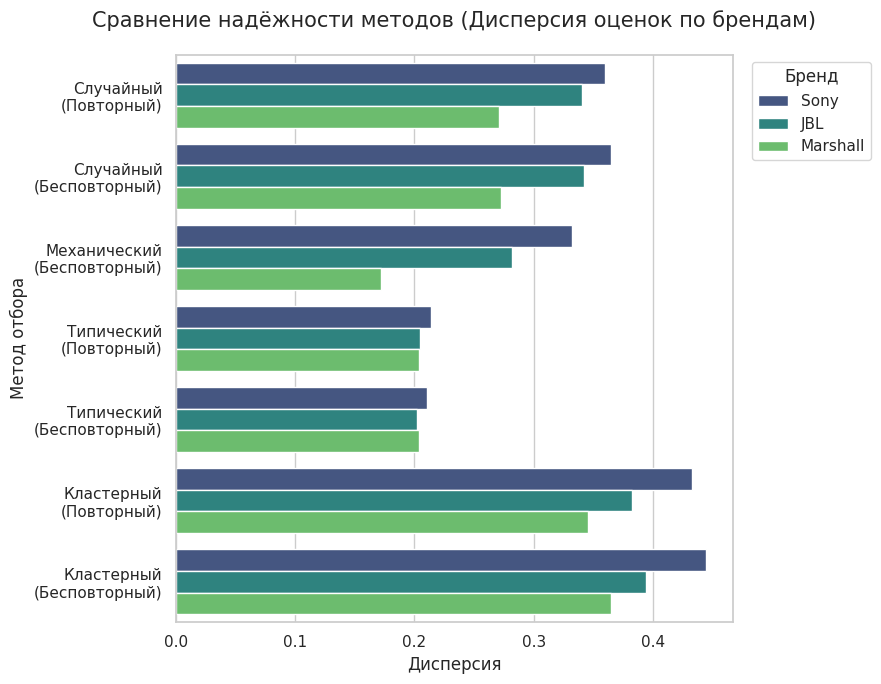

In [12]:
df_plot = df_accuracy.copy()
df_plot["Метод_Подпись"] = (
    df_plot[method] + "\n(" + df_plot[is_rep].astype(str) + ")"
)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(9, 7))  # уже, выше

# barplot с orient="h"
sns.barplot(
    data=df_plot,
    ax=ax,
    y="Метод_Подпись",      # метод — по вертикали
    x="Дисперсия (Var)",    # дисперсия — по горизонтали
    hue="Бренд",
    palette="viridis",
    orient="h",
)

ax.set_xlabel("Дисперсия", fontsize=12)
ax.set_ylabel("Метод отбора", fontsize=12)
ax.set_title(
    "Сравнение надёжности методов (Дисперсия оценок по брендам)",
    fontsize=15,
    pad=20,
)
ax.legend(title="Бренд", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()
